In [14]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

## Low mass

In [113]:
path = str(GLITCH_DATASETS / 'real_glitch_lm_dataset.h5')
with h5py.File(path, 'r') as h5:
    real_images = h5['QT'][:]
real_images = torch.tensor(real_images, dtype=torch.float32)
real_images = real_images.permute(0, 3, 1, 2)

path = str(GLITCH_DATASETS / 'ordinary_glitch_lm_dataset.h5')
with h5py.File(path, 'r') as h5:
    ordinary_images = h5['QT'][:]
    ordinary_betas = h5['beta'][:]
    ordinary_levels = h5['level'][:]
ordinary_images = torch.tensor(ordinary_images, dtype=torch.float32)
ordinary_images = ordinary_images.permute(0, 3, 1, 2)

with h5py.File(glitch_lm_dataset_path, 'r') as h5:
    training_glitches = h5['QT'][:]
    training_betas = h5['beta'][:]
    training_levels = h5['level'][:]

with h5py.File(gw_lm_dataset_path, 'r') as h5:
    training_gws = h5['QT'][:]

with h5py.File(mixed_lm_dataset_path, 'r') as h5:
    training_mixed = h5['QT'][:]

In [15]:
model = CNN(width=8, bn=True)
device = torch.device("mps")
weights_path = TRAINING_RESULTS/'low_mass'/'run_260226_114659'/'model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

### Real glitches

In [118]:
with torch.no_grad():
    outputs = model(real_images.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

target = torch.tensor([0, 1], device=preds.device)

correct = (preds == target).all(dim=1).sum().item()
glitch_only = (preds[:, 1] == 1).sum().item()
total = real_images.shape[0]
print('Accuracy on real LPF glitches:', round(correct/total, 3))
print('Glitch only accuracy:', round(glitch_only/total, 3))

Accuracy on real LPF glitches: 0.872
Glitch only accuracy: 0.927


In [120]:
wrong = torch.where((preds != target).any(dim=1))[0].detach().cpu().numpy()
right = torch.where((preds == target).all(dim=1))[0].detach().cpu().numpy()

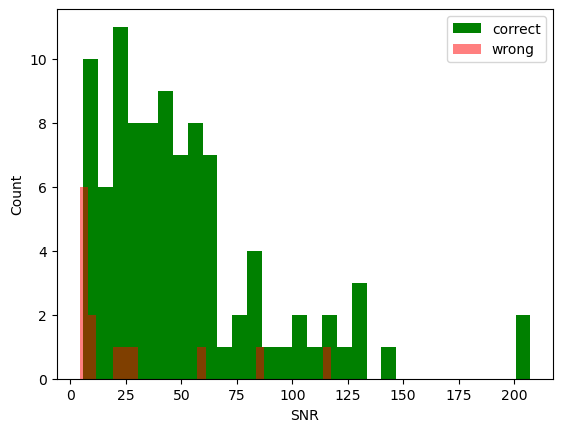

In [121]:
snrs_right = real_images[right].amax(dim=(2,3)).detach().cpu().numpy()
snrs_wrong = real_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()

plt.hist(snrs_right[:, 0], bins=30, color='green', label='correct')
plt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5, label='wrong')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.legend()
plt.show()

The prediction is: tensor([[6.7408e-04, 1.0000e+00]], device='mps:0')


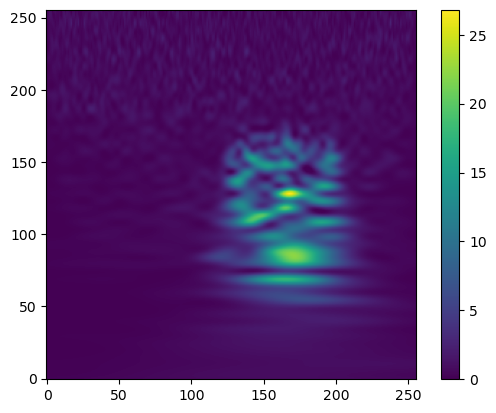

In [67]:
index = 37
image = real_images[index].unsqueeze(0)
with torch.no_grad():
    pred = torch.sigmoid(model(image.to(device)))
print('The prediction is:', pred)

image = real_images[index].detach().cpu().numpy()
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()

### Ordinary params

In [69]:
with torch.no_grad():
    outputs = model(ordinary_images.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

target = torch.tensor([0, 1], device=preds.device)

correct = (preds == target).all(dim=1).sum().item()
glitch_only = (preds[:, 1] == 1).sum().item()
total = ordinary_images.shape[0]
print('Accuracy on glitches with ordinary params:', round(correct/total, 3))
print('Glitch only accuracy:', round(glitch_only/total, 3))

Accuracy on glitches with ordinary params: 0.385
Glitch only accuracy: 0.859


In [83]:
wrong = torch.where((preds != target).any(dim=1))[0].detach().cpu().numpy()
right = torch.where((preds == target).all(dim=1))[0].detach().cpu().numpy()

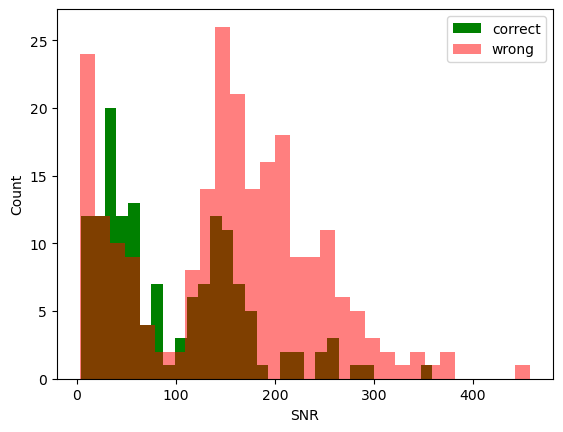

In [106]:
snrs_right = ordinary_images[right].amax(dim=(2,3)).detach().cpu().numpy()
snrs_wrong = ordinary_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()

plt.hist(snrs_right[:, 0], bins=30, color='green', label='correct')
plt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5, label='wrong')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.legend()
plt.show()

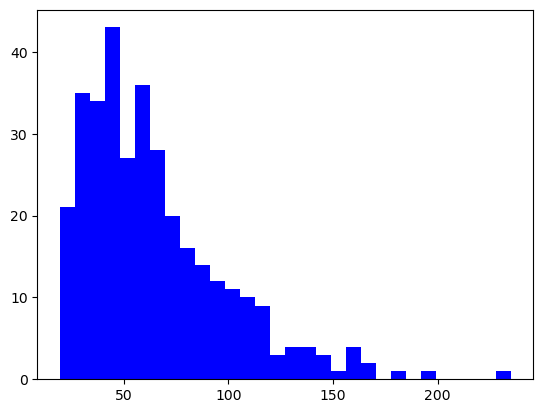

In [109]:
snrs_train_glitch = np.max(training_glitches, axis=(1,2))

plt.hist(snrs_train_glitch[:, 0], bins=30, color='blue')
plt.show()

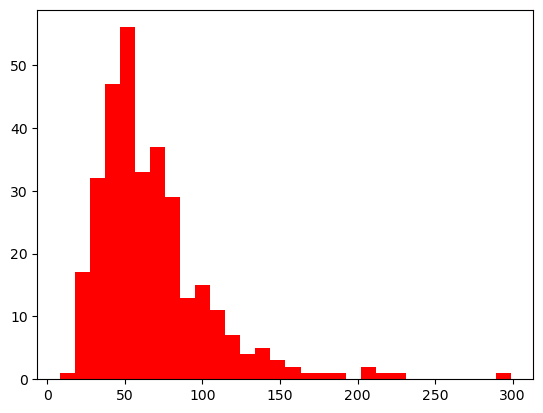

In [114]:
snrs_train_mixed = np.max(training_mixed, axis=(1,2))

plt.hist(snrs_train_mixed[:, 0], bins=30, color='red')
plt.show()

The prediction is: tensor([[0.8387, 0.0157]], device='mps:0')


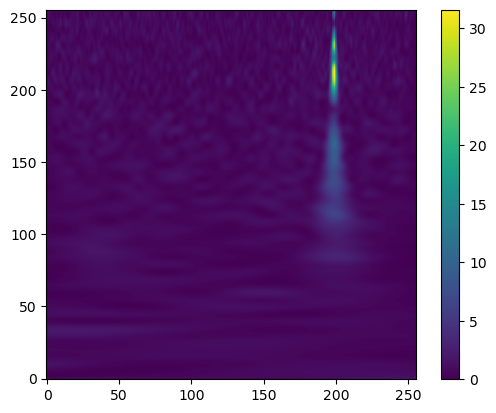

In [117]:
index = 273
image = ordinary_images[index].unsqueeze(0)
with torch.no_grad():
    pred = torch.sigmoid(model(image.to(device)))
print('The prediction is:', pred)

image = ordinary_images[index].detach().cpu().numpy()
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()

## High mass

In [122]:
path = str(GLITCH_DATASETS / 'real_glitch_hm_dataset.h5')
with h5py.File(path, 'r') as h5:
    real_images = h5['QT'][:]
real_images = torch.tensor(real_images, dtype=torch.float32)
real_images = real_images.permute(0, 3, 1, 2)

path = str(GLITCH_DATASETS / 'ordinary_glitch_hm_dataset.h5')
with h5py.File(path, 'r') as h5:
    ordinary_images = h5['QT'][:]
    ordinary_betas = h5['beta'][:]
    ordinary_levels = h5['level'][:]
ordinary_images = torch.tensor(ordinary_images, dtype=torch.float32)
ordinary_images = ordinary_images.permute(0, 3, 1, 2)

with h5py.File(glitch_hm_dataset_path, 'r') as h5:
    training_glitches = h5['QT'][:]
    training_betas = h5['beta'][:]
    training_levels = h5['level'][:]

with h5py.File(gw_hm_dataset_path, 'r') as h5:
    training_gws = h5['QT'][:]

with h5py.File(mixed_hm_dataset_path, 'r') as h5:
    training_mixed = h5['QT'][:]

In [124]:
model = CNN(width=8, bn=True)
device = torch.device("mps")
weights_path = TRAINING_RESULTS/'high_mass'/'run_250226_230238'/'model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

### Real glitches

In [130]:
with torch.no_grad():
    outputs = model(real_images.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

target = torch.tensor([0, 1], device=preds.device)

correct = (preds == target).all(dim=1).sum().item()
glitch_only = (preds[:, 1] == 1).sum().item()
total = real_images.shape[0]
print('Accuracy on real LPF glitches:', round(correct/total, 3))
print('Glitch only accuracy:', round(glitch_only/total, 3))

Accuracy on real LPF glitches: 0.367
Glitch only accuracy: 0.826


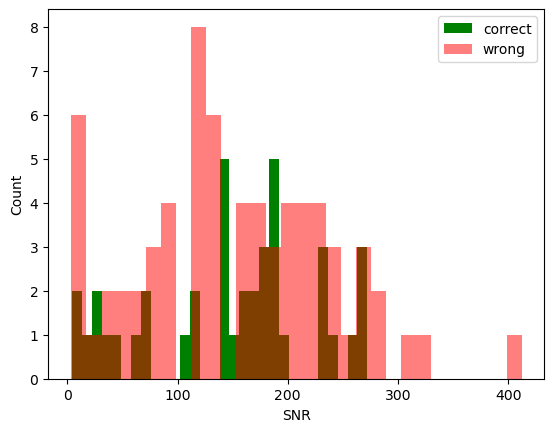

In [131]:
wrong = torch.where((preds != target).any(dim=1))[0].detach().cpu().numpy()
right = torch.where((preds == target).all(dim=1))[0].detach().cpu().numpy()

snrs_right = ordinary_images[right].amax(dim=(2,3)).detach().cpu().numpy()
snrs_wrong = ordinary_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()

plt.hist(snrs_right[:, 0], bins=30, color='green', label='correct')
plt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5, label='wrong')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.legend()
plt.show()

### Ordinary params

In [126]:
with torch.no_grad():
    outputs = model(ordinary_images.to(device).contiguous())
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

target = torch.tensor([0, 1], device=preds.device)

correct = (preds == target).all(dim=1).sum().item()
glitch_only = (preds[:, 1] == 1).sum().item()
total = ordinary_images.shape[0]
print('Accuracy on glitches with ordinary params:', round(correct/total, 3))
print('Glitch only accuracy:', round(glitch_only/total, 3))

Accuracy on glitches with ordinary params: 0.594
Glitch only accuracy: 0.751


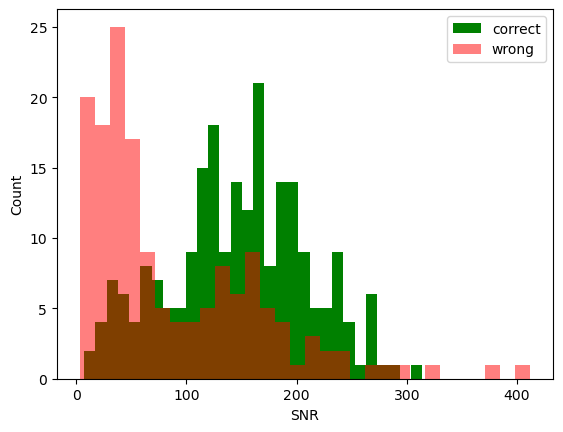

In [129]:
wrong = torch.where((preds != target).any(dim=1))[0].detach().cpu().numpy()
right = torch.where((preds == target).all(dim=1))[0].detach().cpu().numpy()

snrs_right = ordinary_images[right].amax(dim=(2,3)).detach().cpu().numpy()
snrs_wrong = ordinary_images[wrong].amax(dim=(2,3)).detach().cpu().numpy()

plt.hist(snrs_right[:, 0], bins=30, color='green', label='correct')
plt.hist(snrs_wrong[:, 0], bins=30, color='red', alpha=0.5, label='wrong')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.legend()
plt.show()